## Ruta Referencia

* 0 crucero
* 1 ...
* 19 ...
* 20 crucero

In [1]:
import os
# os.chdir('../')
print(os.getcwd())

/home/mbibiloni/Documents/UIB_doctorat/AIMS-tourist_flow_model/cruiseshiptourism


In [22]:
#from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tourist import Tourist 
import tasks as tsk
from vincenty import vincenty
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from scipy.spatial.distance import pdist, squareform

In [3]:
topsights = pd.read_csv(
            "palmadata/palmapointsofinterest_cleaned.csv", 
            header = 0,
            dtype = {
                "place": 'str',
                "description": 'str',
                "latitude": 'float',
                "longitude": 'float',
                "stars": 'float',
                "reviews": 'float',
                "utility": 'float'
            }
        )

In [4]:
topsights.head()

,place,description,latitude,longitude,stars,reviews,utility
0,cruise ship,tourist cruise ship,39.568276,2.637640,0.000000,0.0,0.000000
1,Catedral-Basílica de Santa María de Mallorca,Gothic place of worship on the seafront,39.567425,2.648299,4.674750,31176.0,0.951213
2,Castell de Bellver,Hilltop 1300s castle for panoramic views,39.563814,2.619354,4.436243,10446.0,0.749203
3,Royal Palace of La Almudaina,Historic palace of the Royal Family,39.567886,2.647022,4.420346,2310.0,0.681576
4,Tren Soller,Scenic electric railway dating to 1912,39.576665,2.653782,4.396561,5757.0,0.705649


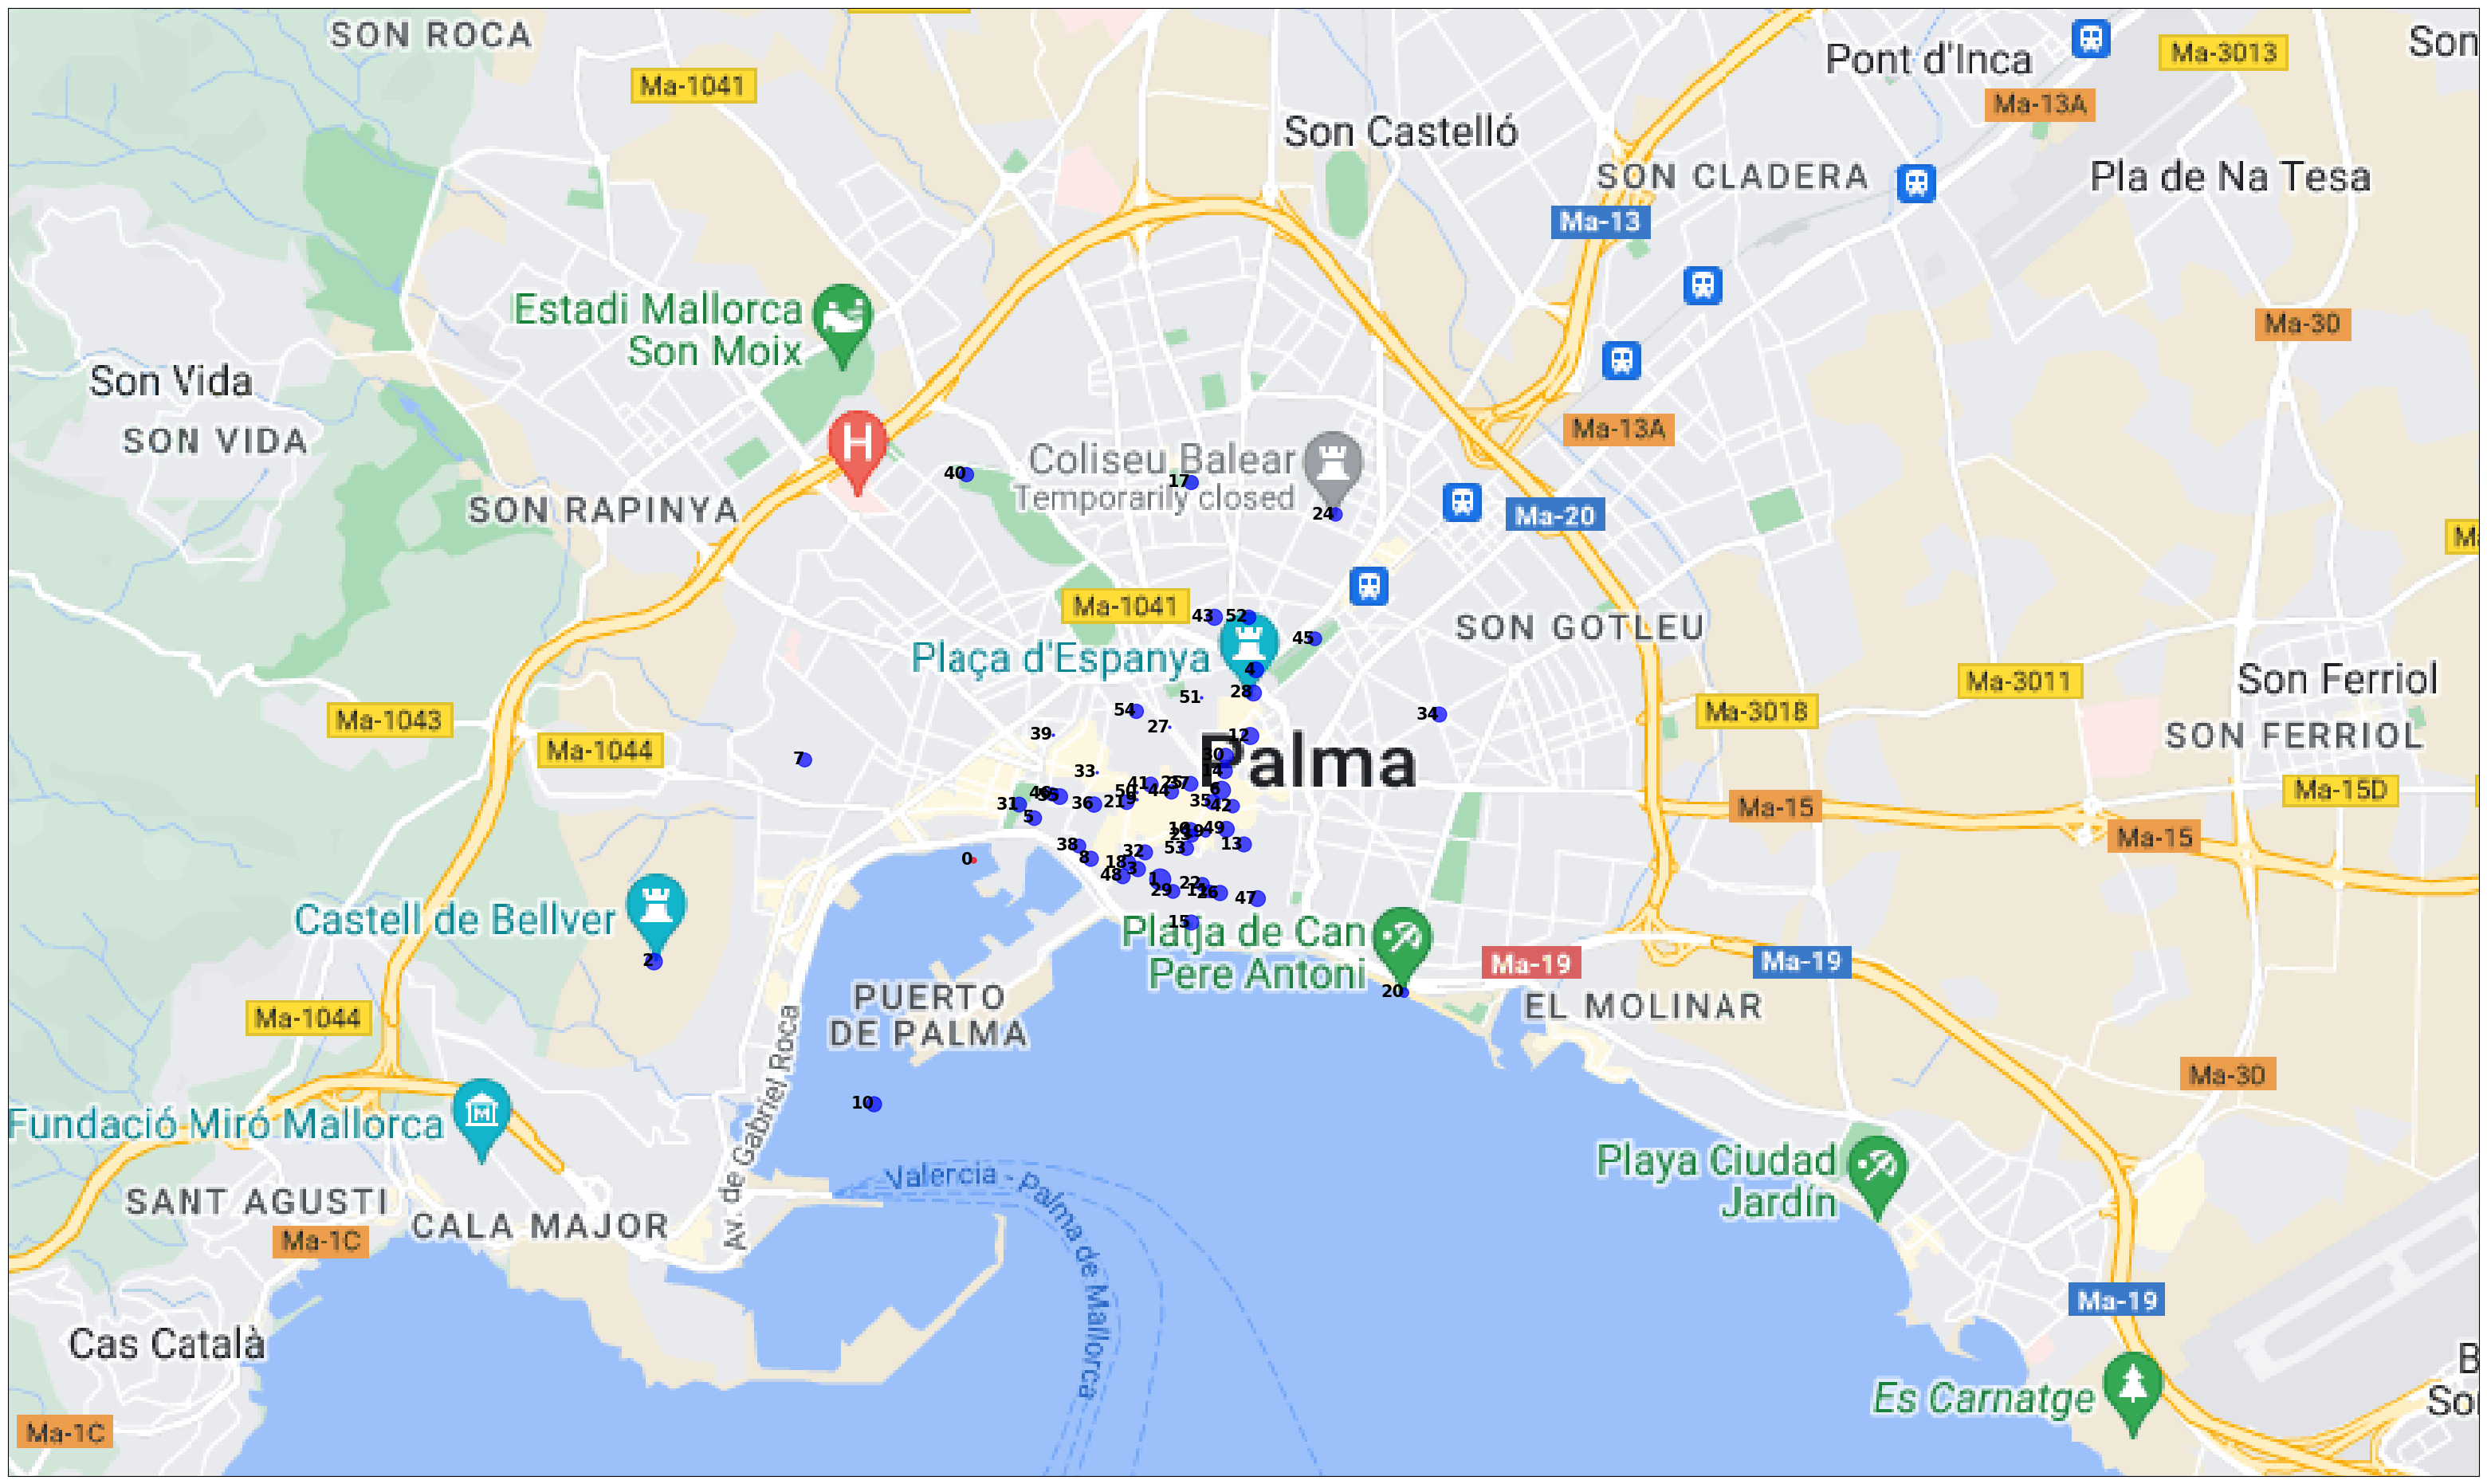

In [13]:
# values
latitude = topsights.latitude.values
longitude = topsights.longitude.values
utility = topsights.utility.values

center = {"place":"center of Palma",
          "latitude": 39.571533,
          "longitude": 2.651444}

# Map background
ffig = plt.figure(figsize=(40,50))

tiler = cimgt.GoogleTiles()
mercator = tiler.crs
ax = plt.axes(projection=mercator)

llcrnrlat=39.541089  # The lower left corner geographical latitude
llcrnrlon=2.582399   # The lower left corner geographical longitude
urcrnrlat=39.605874  # The upper right corner geographical latitude
urcrnrlon=2.723818   # The upper right corner geographical longitude


ax.set_extent([llcrnrlon,urcrnrlon, llcrnrlat, urcrnrlat], ccrs.PlateCarree())

zoom = 13
ax.add_image(tiler, zoom )

for i in range(1,len(latitude)):
    plt.plot(longitude[i], latitude[i], marker='o', color='blue', markersize=utility[i]*20, lw=0,
             alpha=0.7, transform=ccrs.Geodetic())
    
plt.plot(longitude[0], latitude[0], marker='o', color='red', markersize=5, lw=0,
         alpha=0.7, transform=ccrs.Geodetic())

plt.plot(center["longitude"], center["latitude"], marker='o', color='black', markersize=5, lw=0,
         alpha=0.7, transform=ccrs.Geodetic())

labels = range(len(latitude))
labels = [str(i) for i in labels]
zip_object = zip(longitude, latitude, labels)
for (lg, lt, ne) in zip_object:
    ax.text(lg, lt, 
            ne, 
            va='center', 
            ha='right',
            size=15,
            transform=ccrs.Geodetic(), fontweight='bold')

* 0  - 38 - 8 - 48 - 18 - 32 - 3  - 1  - 53 - 49
* 35 - 6 - 57 - 44 - 41 - 21 - 36 - 55 - 31 - 5

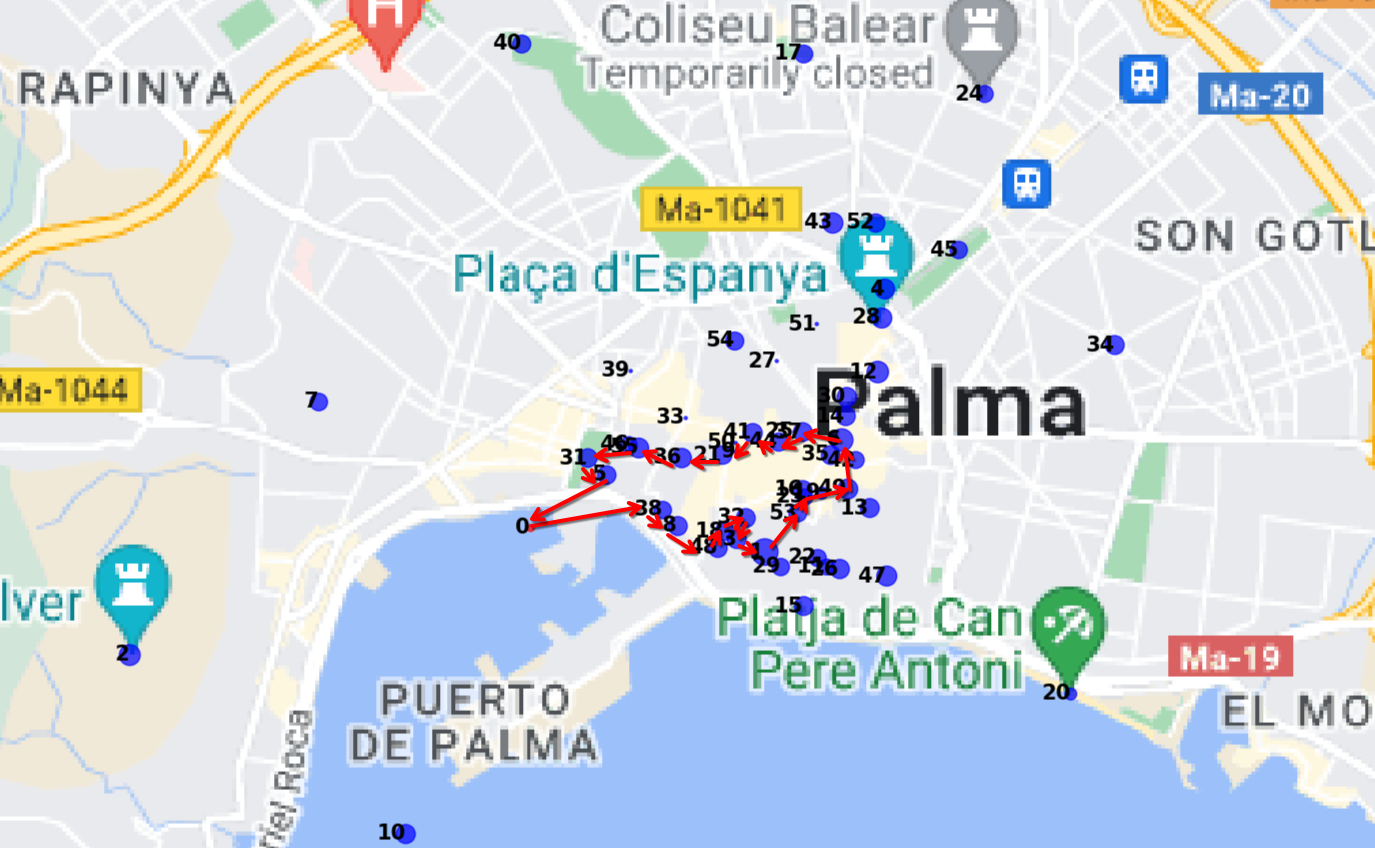

In [44]:
ruta_ref = [0, 38, 8, 48, 18, 32, 3, 1, 53, 49, 35, 6, 37, 44, 41, 21, 36, 55, 31, 5]

In [20]:
df_ruta_ref = topsights.loc[ruta_ref]
df_ruta_ref

,place,description,latitude,longitude,stars,reviews,utility
0,cruise ship,tourist cruise ship,39.568276,2.637640,0.000000,0.0,0.000000
38,Consolat de Mar de Palma,Local government office,39.568916,2.643669,4.142857,14.0,0.621541
8,Lonja de Mallorca,Historic building with Gothic design,39.568358,2.644337,4.441206,1956.0,0.681866
48,"Estàtua ""Es Foner""",Sculpture,39.567574,2.646157,4.473684,38.0,0.671357
18,Hort del Rei,Garden and park,39.568156,2.646482,4.413043,598.0,0.666752
32,Fundación Bartolomé March,Art & antique books in an elegant space,39.568639,2.647461,4.508197,122.0,0.677208
3,Royal Palace of La Almudaina,Historic palace of the Royal Family,39.567886,2.647022,4.420346,2310.0,0.681576
1,Catedral-Basílica de Santa María de Mallorca,Gothic place of worship on the seafront,39.567425,2.648299,4.674750,31176.0,0.951213
53,Ca'n Oms,Historical landmark,39.568796,2.649844,4.250000,8.0,0.637564
49,Can Vivot,Tourist attraction,39.569659,2.652085,4.750000,16.0,0.712628


## Operador dist referència

In [25]:
lat = df_ruta_ref.latitude
lon = df_ruta_ref.longitude
coor_list = list(zip(lat, lon))
dist_matrix = pd.DataFrame(np.row_stack(squareform(pdist(coor_list, lambda p1, p2: vincenty(p1, p2, miles=False)))))

In [49]:
dist_matrix

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.000000,0.522909,0.575505,0.736037,0.759877,0.844860,0.807367,0.920818,1.050304,1.250708,1.208568,1.265423,1.131218,1.027669,0.945350,0.803602,0.654258,0.528263,0.352955,0.363052
1,0.522909,0.000000,0.084401,0.260599,0.255976,0.327280,0.309968,0.430929,0.530819,0.727877,0.690461,0.751043,0.627634,0.525281,0.462461,0.316156,0.217184,0.260522,0.354710,0.258304
2,0.575505,0.084401,0.000000,0.179049,0.185683,0.270271,0.236637,0.355926,0.475773,0.681303,0.659637,0.724335,0.612867,0.513954,0.466929,0.326538,0.266071,0.340329,0.437426,0.340397
3,0.736037,0.260599,0.179049,0.000000,0.070401,0.162856,0.082013,0.184802,0.344640,0.559490,0.572614,0.643384,0.563331,0.479341,0.470567,0.362426,0.378541,0.498180,0.615305,0.518709
4,0.759877,0.255976,0.185683,0.070401,0.000000,0.099748,0.055267,0.176027,0.297552,0.509575,0.511064,0.580772,0.495063,0.409479,0.400678,0.297336,0.332211,0.468565,0.605464,0.511224
5,0.844860,0.327280,0.270271,0.162856,0.099748,0.000000,0.091638,0.152796,0.205558,0.413177,0.411521,0.481567,0.402129,0.323314,0.332873,0.260489,0.342619,0.500800,0.660244,0.570397
6,0.807367,0.309968,0.236637,0.082013,0.055267,0.091638,0.000000,0.121112,0.262683,0.477482,0.493588,0.564963,0.492747,0.414936,0.420171,0.331678,0.382192,0.522834,0.660557,0.566085
7,0.920818,0.430929,0.355926,0.184802,0.176027,0.152796,0.121112,0.000000,0.201934,0.409047,0.459521,0.532094,0.492876,0.435635,0.469020,0.412477,0.489790,0.639051,0.781484,0.687175
8,1.050304,0.530819,0.475773,0.344640,0.297552,0.205558,0.262683,0.201934,0.000000,0.215067,0.260173,0.332268,0.317421,0.290731,0.362232,0.373305,0.503883,0.674718,0.850555,0.765032
9,1.250708,0.727877,0.681303,0.559490,0.509575,0.413177,0.477482,0.409047,0.215067,0.000000,0.147964,0.191586,0.281200,0.327388,0.431720,0.506543,0.658581,0.832242,1.022594,0.944387


In [45]:
ruta_ref_2 = ruta_ref[1:len(ruta_ref)]
ruta_ref_2.append(0)

In [48]:
print(ruta_ref)
ruta_ref_2

[0, 38, 8, 48, 18, 32, 3, 1, 53, 49, 35, 6, 37, 44, 41, 21, 36, 55, 31, 5]


[38, 8, 48, 18, 32, 3, 1, 53, 49, 35, 6, 37, 44, 41, 21, 36, 55, 31, 5, 0]

In [70]:
dist_ref_list = []
idx = [ i for i in range(len(ruta_ref))]
for i in idx[0:len(idx)-1]:
    dist_ref_list.append(dist_matrix.loc[i].loc[i+1])
dist_ref_list.append(dist_matrix.loc[19].loc[0])

In [78]:
sum(dist_ref_list)

3.3142340000000003

In [75]:
sum(dist_ref_list)*6500

21542.521

pasando por castillo (ultimo):

In [91]:
ruta_ref_castell = [0, 38, 8, 48, 18, 32, 3, 1, 53, 49, 35, 6, 37, 44, 41, 21, 36, 55, 31, 5, 2, 0]
df_ruta_ref_castell = topsights.loc[ruta_ref_castell]

lat_castell = df_ruta_ref_castell.latitude
lon_castell = df_ruta_ref_castell.longitude
coor_list_castell = list(zip(lat_castell, lon_castell))
dist_matrix_castell = pd.DataFrame(np.row_stack(squareform(pdist(coor_list_castell, lambda p1, p2: vincenty(p1, p2, miles=False)))))

dist_ref_list_castell = []
idx_castell = [ i for i in range(len(ruta_ref_castell))]
for i in idx_castell[0:len(idx_castell)-1]:
    dist_ref_list_castell.append(dist_matrix_castell.loc[i].loc[i+1])
dist_ref_list_castell.append(dist_matrix_castell.loc[19].loc[0])

sum(dist_ref_list_castell)*6500

45233.539

In [92]:
sum(dist_ref_list_castell)

6.959006

exemple turista:

In [80]:
ruta_tur = [0,36,8,45,5,31,23,16,29,30,24,2,55,55,19,10,2,54,22,11,0]
df_ruta_tur = topsights.loc[ruta_tur]

In [81]:
df_ruta_tur

,place,description,latitude,longitude,stars,reviews,utility
0,cruise ship,tourist cruise ship,39.568276,2.637640,0.000000,0.0,0.000000
36,Gerhardt Braun Gallery,Art and art museum,39.570749,2.644551,4.625000,8.0,0.693814
8,Lonja de Mallorca,Historic building with Gothic design,39.568358,2.644337,4.441206,1956.0,0.681866
45,Parc de les Estacions,City park,39.578044,2.657172,3.984568,2592.0,0.618470
5,Es Baluard Museu d'Art Contemporani de Palma,Modern & contemporary art collection,39.570139,2.641112,4.257859,2513.0,0.658831
31,Sa Feixina Park,Park,39.570722,2.640264,4.318126,2455.0,0.667406
23,Ayuntamiento de Palma de Mallorca,City or town hall,39.569381,2.650158,3.832258,155.0,0.576082
16,Plaça de Cort,Hiking area,39.569622,2.650072,4.500000,2.0,0.675016
29,Museu Diocesà de Mallorca,Religious museum in a 1200s palace,39.566906,2.649057,4.139535,43.0,0.621275
30,Basilica of St. Michael,Catholic church,39.572883,2.652049,4.552311,822.0,0.689438


In [84]:
lat_tur = df_ruta_tur.latitude
lon_tur = df_ruta_tur.longitude
coor_list_tur = list(zip(lat_tur, lon_tur))
dist_matrix_tur = pd.DataFrame(np.row_stack(squareform(pdist(coor_list_tur, lambda p1, p2: vincenty(p1, p2, miles=False)))))

dist_ref_list_tur = []
idx_tur = [ i for i in range(len(ruta_tur))]
for i in idx_tur[0:len(idx_tur)-1]:
    dist_ref_list_tur.append(dist_matrix_tur.loc[i].loc[i+1])
dist_ref_list_tur.append(dist_matrix_tur.loc[19].loc[0])


In [85]:
sum(dist_ref_list_tur)

23.658756000000004

In [87]:
len(ruta_tur)

21

In [88]:
len(ruta_ref)

20